In [1]:
import numpy as np
import pandas as pd
from scipy import fft
import matplotlib.pyplot as plt

In [2]:
traces = pd.read_csv("../traces.dat", delimiter="\t")
tc = traces[6000:-6000].reset_index(drop=True).values.flatten()

def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

In [3]:
noise = remove_signal(tc, 4)

In [6]:
N = len(noise)
dt = 5*10**(-9)
fourier = fft.rfft(noise)
nu = np.sqrt(2)*dt*fourier
omega = 2*np.pi * np.fft.rfftfreq(N, d=dt)

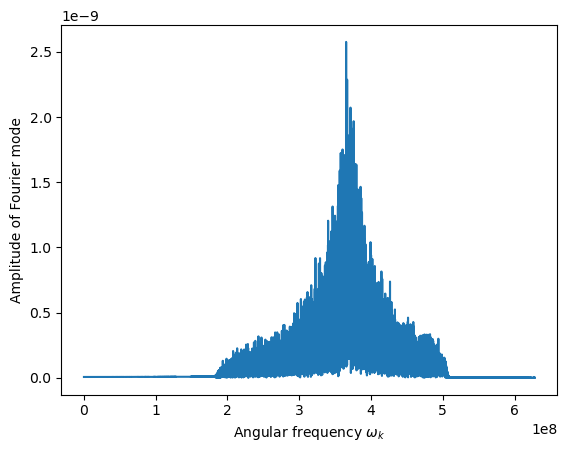

In [9]:
plt.plot(omega, np.abs(nu))
plt.ylabel("Amplitude of Fourier mode")
plt.xlabel(r"Angular frequency $\omega_k$")
plt.show()